# Tutorial 1 - ghostID parameter optimization and trouble-shooting

While using `ghostID` is simple, successfull identification of ghosts can be tricky depending on the system and the type of ghost. `ghostID` has a number of hyperparameters you can tune and features that can help you finding the correct parameter values for your case. This tutorial shows you how to do that.

## Using ghostID's control outputs

GhostID utilizes maxima of the function $pQ(t) = -\textnormal{log}(\frac{||f(x,\rho)||^2}{2})$ to identify slow points along a trajectory as candidates for ghosts and checks if one or more eigenvalues along the trajectory changes sign from negative to positive within a small neighborhood of the slow points. As central quantities of evaluation, `ghostID` provides control plots that allow visual inspection of $pQ$ values and eigenvalues and provide important clues which help to optimize parameters and figure out potential issues related to the identification of ghosts in a system of interest. Let's use the normal form example from the basic usage tutorial to look at these control plots. To do that, we have to set the following kwargs when calling ghostID: `ctrlOutputs={"ctrl_qplot":True,"ctrl_evplot":True}`

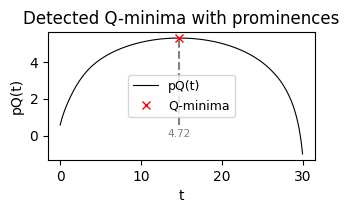

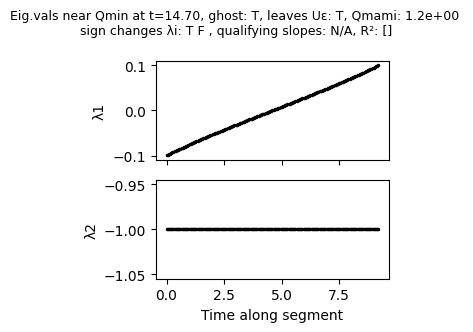

: 

In [ ]:
# imports
import numpy as np
import jax.numpy as jnp
from scipy.integrate import solve_ivp
import PyGhostID as gid

# define model
def normalform_SN_bifurcation(t,z,para):

    mu=para[0]
    dx = mu + z[0]**2
    dy= -z[1]
         
    return jnp.stack([dx, dy])

# set model parameters
mu = 0.01

# set time parameters
dt = 0.05
t_end = 30
timesteps = np.linspace(0,t_end,int(t_end/dt))

# initial conditions
x0 = -1
y0 = 0.5

# run simulation
sol = solve_ivp(normalform_SN_bifurcation, (0, t_end), [x0,y0], t_eval=timesteps, args=([mu],),method='RK45')

# extract trajectory
trajectory=sol.y.T

# run ghostID
ghostSeq = gid.ghostID(normalform_SN_bifurcation,[mu],dt,trajectory, ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True})

The first plot shows the $pQ(t)$ profile along with identified maxima/peaks (in this case only one) and their prominence, i.e. height over the local baseline. The second plot shows the eigenvalues along the trajectory within the neighborhood of the identified slow points. It shows that the first eigenvalue $\lambda_1$ increases almost linearly from $-0.1$ to $0.1$, thus confirming that we have found a ghost. The second eigenvalue does not change and stays negative within the neighborhood considered. The title of the second plot also features some additional information:
- the time at which the Q-minimum (=pQ-maximum), i.e., the slowest point along this trajectory segment, is found
- whether the algorithm considers the slow point to be a ghost
- whether the trajectory leaves the neighborhood of the slow point eventually
- Qmami: ratio of the maximum and the minimum eigenvalue along the trajectory segment
- whether any of the eigenvalues change sign
- if the indirect eigenvalue criterion is enabled: whether eigenvalue slopes are considered within range and what the R² value of the linear fit is

By default, ghostID shows the control plots on its own. If you want to modify these plots or only look at selected control plots from multiple ghosts, you can set `ctrlOutputs={"ctrl_qplot":True,"ctrl_evplot":True,"return_ctrl_figs":True}` in which case ghostID will simply return the selected types of control plots without showing them.

## Optimizing parameters for identification of slow points

Identification of slow points from the $pQ(t)$ profile of a trajectory can fail due to various reasons such spurious peaks or too many peaks due to numerical settings. Often, these can be resolved by lowering the numerical tolerances of the simulation - at the expense of longer runtimes. If that is not feasible, ghostID offers a number of ways of optimizing identification of slow points. Let us consider a two-dimensional model from [Bieg et al.](https://link.springer.com/article/10.1007/s10021-023-00892-8) shown to have a ghost. For illustrative purposes, we'll use poor numerical tolerances to run the simulation and then apply ghostID to the resulting trajectory:

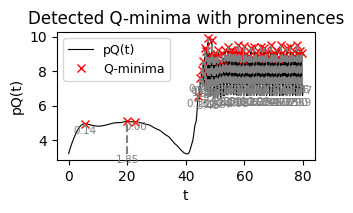

In [6]:
def bieg_etal(t,z,para):

    a,Nt,N0,g,y,r,c,m = para
    B = 1-z[0]-z[1]
    dC = z[0]*(r*(1-c*Nt)*B-m-a*z[1]*(Nt/(N0+Nt)))
    dM = z[1]*(a*z[0]*(Nt/(N0+Nt))-g/(z[1]+B)+y*B)

    return jnp.array([dC, dM])

# set parameters
a = 2.0; y = 0.7; m = 0.15; g = 0.4; Nt = 0.53; N0 = 0.5; r = 1.8; c = 0.25
parameters_bieg =  [a,Nt,N0,g,y,r,c,m]

# set time parameters
dt = 0.05
t_end = 80
timesteps = np.linspace(0,t_end,int(t_end/dt))

# simulate trajectory 
sol = solve_ivp(bieg_etal, (0, t_end), [0.07,0.6], t_eval=timesteps, args=(parameters_bieg,),method='RK45',rtol=1e-3,atol=5e-4)

# run ghostID
Trj_bieg=sol.y.T
ghostSeq = gid.ghostID(bieg_etal,parameters_bieg,dt,Trj_bieg,ctrlOutputs={"ctrl_qplot":True},display_warnings=False)

As you can see, the $pQ(t)$ profile features a single clear peak between t=5 and t=10, followed by another broader peak at about t=20. However, ghostID erroneously  found 2 peaks here. After t=45 or so, we can see a plethora of additional peaks due to numerical noise once the trajectory has reached a fixed point. Luckily these don't slow down ghostID as the algorithm automatically detects that the trajectory does not leave the neighborhood of the fixed point / equilibrium, hence it cannot be a ghost which is a transient state. However, spurious peaks can lead to identification of multiple ghosts where there is only one ghosts. GhostID has several ways to prevent this but starting with detecting only "real" peaks in the $pQ(t)$ profile is always a good idea. Since ghostID relies on SciPy's `find_peaks` function, we can use any of its [kwargs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html) to alter peak identification behavior. To do so, we can use ghostID's kwarg `peak_kwargs`, which in turns can contain all kwargs accepted by `find_peaks`.

Let us start with filtering peaks by prominence and consider only peaks with a prominence of at 0.1 above the local baseline:

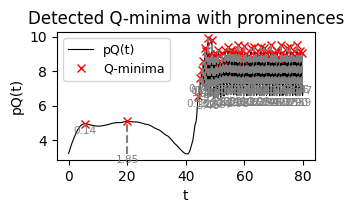

In [7]:
ghostSeq = gid.ghostID(bieg_etal,parameters_bieg,dt,Trj_bieg,peak_kwargs={"prominence":0.1},ctrlOutputs={"ctrl_qplot":True},display_warnings=False)

This removed the spurious peaks at around t=20 which now appears only as a single peak. However, the peaks after t>45 still persists.
While not necessary in this case, we can further clean up our $pQ(t)$ profile by using the `width`  parameter. Requiring all peaks to have a minium width of at least 10 leaves us with only the two slow points that we'd expect from checking the profile by eye:

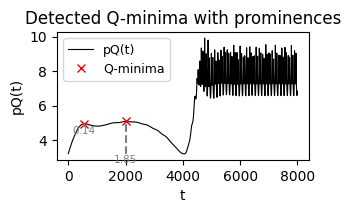

In [19]:
ghostSeq = gid.ghostID(bieg_etal,parameters_bieg,dt,Trj_bieg,peak_kwargs={"prominence":0.1, "width":10},ctrlOutputs={"ctrl_qplot":True},display_warnings=False)

## Issues with eigenvalue profiles

Even if pQ(t) profiles are flawless, identification of ghosts can fail due issues with the eigenvalue profiles of a trajectory segment in the neighborhood of a slow point. Sometimes, eigenvalue profiles are discontinuous or scattered, violating the required monotic crossing from negative to positive eigenvalues. This can happen because eigenvalue indexing along a trajectory segment is not guaranteed to be consistent across consecutive time steps due to numerical reasons (i.e. $\lambda_1$ at time $t$ may be labeled $\lambda_2$ at time $t+1$). As an example we consider a simple GRN model from [Farjami et al.](https://doi.org/10.1098/rsif.2021.0442) which is organized close to three co-occuring SNIC bifurcations so that the trajectory on the limit cycle has to pass through three different ghosts:

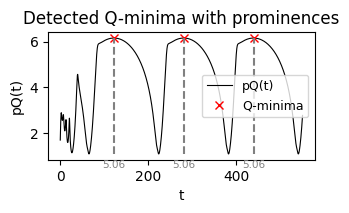

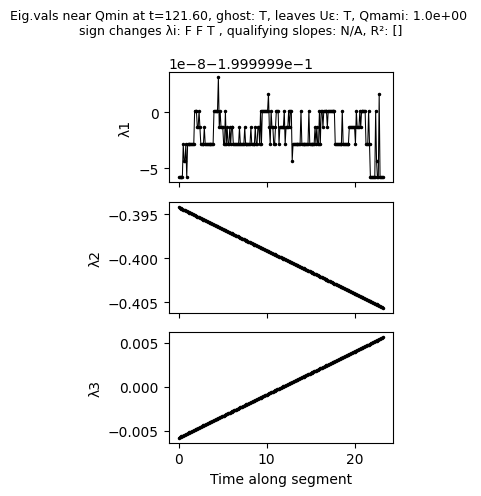

Error in evaluating sign change of eigenvalues: monotonicity violated. 


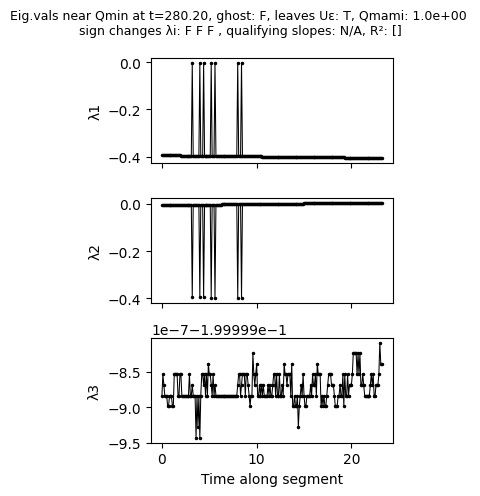

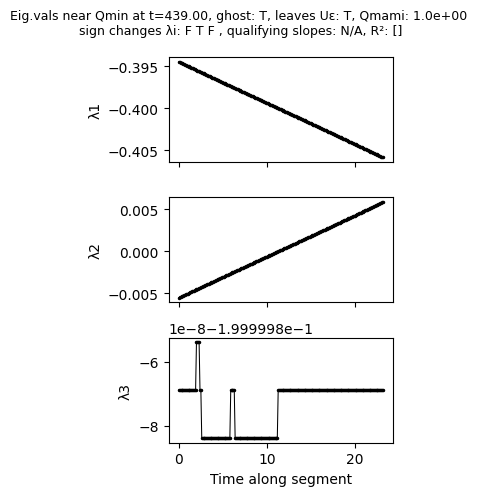

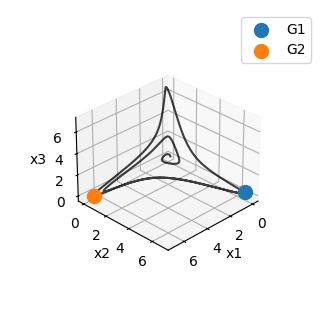

In [ ]:
def farjami_etal(t,x,p):
  
    g = p
    
    g1 = g; g2 = g; g3 = g
    
    b1 = 1e-5; b2 = 1e-5; b3 = 1e-5
    alpha1 = 9; alpha2 = 9; alpha3 = 9
    beta1 = 0.1; beta2 = 0.1; beta3 = 0.1
    h = 3
    d1 = 0.2; d2 = 0.2; d3 = 0.2
    
    dx1 = b1 + g1 / ((1+alpha1*(x[1]**h))*(1+beta1*(x[2]**h))) - d1*x[0]
    dx2 = b2 + g2 / ((1+alpha2*(x[2]**h))*(1+beta2*(x[0]**h))) - d2*x[1]
    dx3 = b3 + g3 / ((1+alpha3*(x[0]**h))*(1+beta3*(x[1]**h))) - d3*x[2]
    
    return jnp.array([dx1, dx2, dx3])


# set parameters
g_Farjami=1.5

# set time parameters
t_end = 550
dt = 0.1
timesteps = np.linspace(0,t_end,int(t_end/dt))

# simulate trajectory 
ICs = [0.6,0.8,0.8]
sol = solve_ivp(farjami_etal, (0, t_end), ICs,
                    t_eval=timesteps, args=(g_Farjami,),method='RK45',rtol=1e-6,atol=1e-6)

# run ghostID
Trj_farjami=sol.y.T
ghostSeq = gid.ghostID(farjami_etal,g_Farjami,dt,Trj_farjami,peak_kwargs={"prominence":5,"width":200,"distance":20},
                                                     ctrlOutputs={"ctrl_qplot":True,"ctrl_evplot":True})


# plot identified ghosts in 3D
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(projection='3d')
ax.plot(Trj_farjami[:,0],Trj_farjami[:,1],Trj_farjami[:,2],color='k',alpha=0.75)
for g in ghostSeq:
    ax.scatter(g["position"][0],g["position"][1],g["position"][2],s=100,marker="o",label=g["id"])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_box_aspect(None, zoom=0.65)
ax.view_init(elev=30, azim=45)
plt.legend()

The $pQ(t)$ profile look fine and as you can see, ghostID correctly identified two of the three ghosts, but missed the third one.

Looking at the eigenvalue control plots we can see that eigenvalue profiles often look scattered or discontinuous. More often than not the scattering happens on a very small scale (look at the scaling of the y-axis!) and so can be disregarded as numerical noise. However, looking at $\lambda_1$ and $\lambda_2$ of the slow point at t=280.2, we can see that we have large scale discontinuities that are unlikely due to numerical noise. Looking further at the absolute values of both eigenvalue profiles, it looks like the values of $\lambda_1$ and $\lambda_2$ have been occasionally swapped - likely due to a change of indices by the numerical procedure to estimate eigenvalues. Such discontinuities also cause ghostID to throw the error message:

`Error in evaluating sign change of eigenvalues: monotonicity violated.`

However, this error is not specific for the issue and, as we will see below, can also result in other contexts. GhostID has two ways of dealing with this issue: outlier removal and eigenvalue sorting. For outlier removal, we simple use the kwarg `ev_outlier_removal=True`:

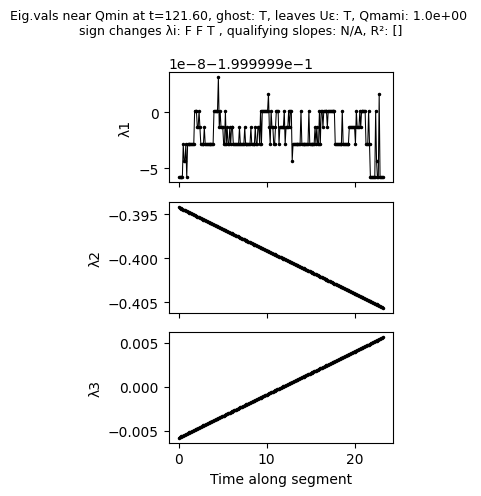

Error in evaluating sign change of eigenvalues: monotonicity violated. Trying outlier removal...
... success.


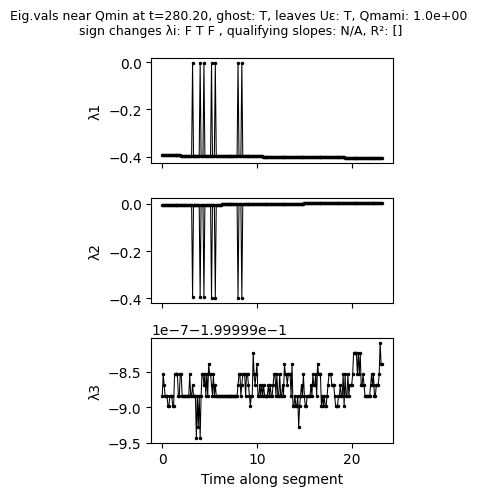

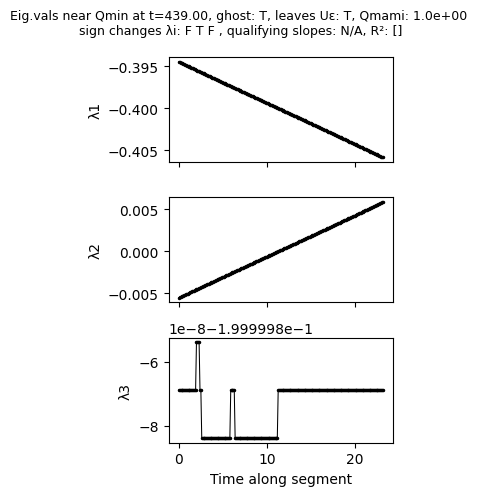

In [10]:
ghostSeq = gid.ghostID(farjami_etal,g_Farjami,dt,Trj_farjami,peak_kwargs={"prominence":5,"width":200,"distance":20},
                                                     ev_outlier_removal=True,
                                                     ctrlOutputs={"ctrl_qplot":False,"ctrl_evplot":True})


While the eigenvalue profile has not changed, the outlier removal leads ghostID to ignore the outlier for evaluating the eigenvalue criterion, leading to successful identification of the third ghost in the system. This is also reflected by the message "Error in evaluating sign change of eigenvalues: monotonicity violated. Trying outlier removal... ... success." which ghostID returns.

Outlier removal is based on a deviation cutoff within a moving window along the eigenvalue profile. If necessary, cutoff and size of the moving window can be further fine-tuned - see API reference for details.

While outlier removal works well for limited local discontinuities in the eigenvalue profiles, it will fail for more complex scattering of eigenvalue profiles. In such cases, we can resort to sorting eigenvalues from scratch using a nearest-neighbour prediction via the kwarg `eigval_NN_sorting=True`:

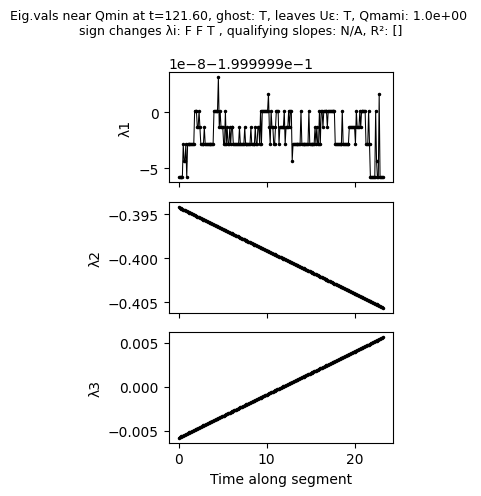

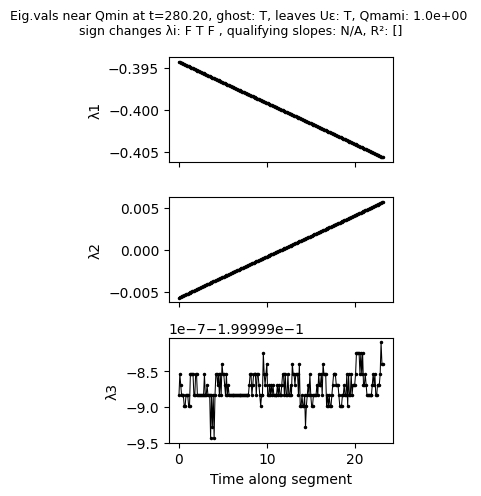

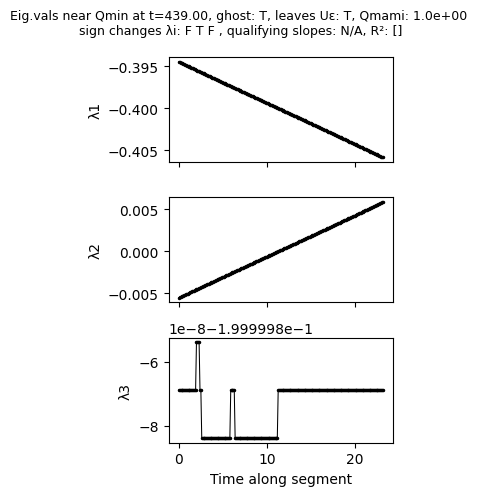

In [11]:
ghostSeq = gid.ghostID(farjami_etal,g_Farjami,dt,Trj_farjami,peak_kwargs={"prominence":5,"width":200,"distance":20},
                                                     eigval_NN_sorting=True,
                                                     ctrlOutputs={"ctrl_qplot":False,"ctrl_evplot":True})

As we can see, the eigenvalue sorting removed the scattering of $\lambda_1$ and $\lambda_2$ by correctly re-assigning the scattered values to the right eigenvalue labels, thereby enabling correct ghost identification.

## Choosing the size of the neighborhood around identified slow points

The parameter `epsilon_gid` controls the size of the neighborhood around a slow point and thus the size of the trajectory segment along which to assess eigenvalues. The default value is `epsilon_gid = 0.05` which we found to work fine in many systems that we have considered but the appropriate value very much depends on the spatial and time scales of the system of interest. Looking at the eigenvalue profiles helps to find an appropriate value. To illustrate this, we return to the simple ecological model introduced above. Starting with `epsilon_gid = 0.01`, we can see that although the eigenvalues at the beginning of the trajectory segment at about $t=40$ are very close to zero, the trajectory segment is too short to capture the crossing of eigenvalues from negative to positive:

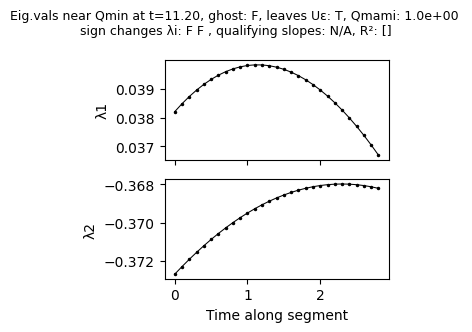

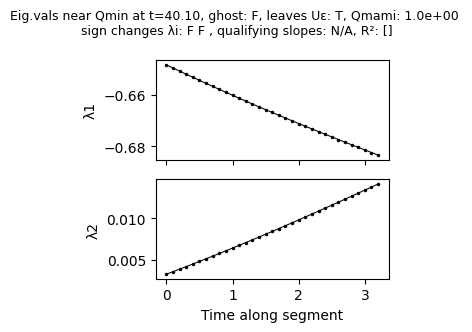

In [12]:
ghostSeq = gid.ghostID(bieg_etal,parameters_bieg,dt,Trj_bieg,epsilon_gid = 0.01,peak_kwargs={"prominence":0.1, "width":10},ctrlOutputs={"ctrl_qplot":False,"ctrl_evplot":True})

As before, using the default value `epsilon_gid = 0.05` is sufficient to capture the crossing of eigenvalue $\lambda_2$ from negative to positive:

Error in evaluating sign change of eigenvalues: monotonicity violated. 


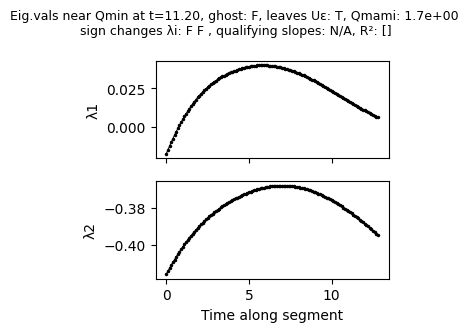

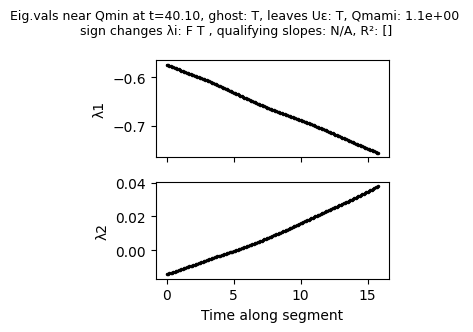

In [13]:
ghostSeq = gid.ghostID(bieg_etal,parameters_bieg,dt,Trj_bieg,epsilon_gid = 0.05,peak_kwargs={"prominence":0.1, "width":10},ctrlOutputs={"ctrl_qplot":False,"ctrl_evplot":True})


However, increasing further, e.g., to `epsilon_gid = 0.15`, leads to a violation of the monotonicity condition required by algorithm: $\lambda_1$ declines for a while before increasing again and crossing from negative to positive values.

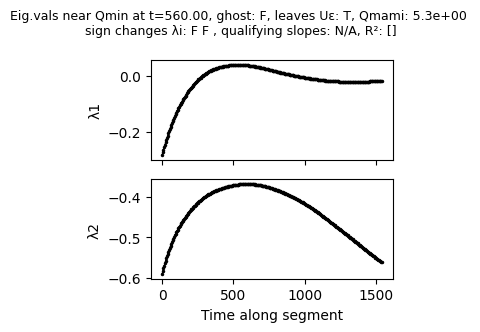

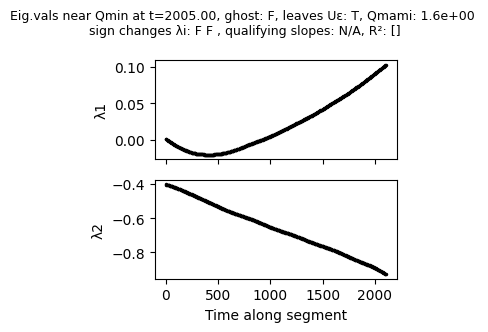

In [21]:
ghostSeq = gid.ghostID(bieg_etal,parameters_bieg,dt,Trj_bieg,epsilon_gid = 0.15,peak_kwargs={"prominence":0.1, "width":10},eigval_NN_sorting=True,ctrlOutputs={"ctrl_qplot":False,"ctrl_evplot":True})

As a general rule, ghost identification works best if the size of the segment is chosen large enough such that eigenvalues cross from negative to positive roughly at the center of eigenvalue control plots and small enough to avoid non-monotic eigenvalue profiles resulting from visiting other areas of the phase space.

## Identifying too many or too few ghosts

Depending on the system, the numerical approach and the initial conditions, it can happen that ghostID identifies multiple ghosts where there is only a single ghost present. This may occur, for example, in a ghost cycle where, depending on the initial conditions, a trajectory visits a ghost multiple times but the first time the trajectory did not pass through the center of the ghost and just about captured the eigenvalue crossing, whereas in subsequent visits it passes through the center of the ghost. Another frequent situation is the use of multiple trajectories to identify as many ghosts as possible in a phase space area of interest.

For the first case, we consider again the GRN leading to a ghost cycle that we used above to illustrate issues that can occur with the eigenvalue profiles. This time, we use slightly different parameters (g = 1.49 instead of g = 1.5) and different initial conditions. If a trajectory visits a ghost twice, ghostID automatically checks if it has already identified this ghost previously using a distant threshold (`delta_gid`) before assigning an identitifier to a ghost. Since the default value `delta_gid = 0.1` is sufficient to prevent the issue, we have to lower it to `delta_gid=0.01`:

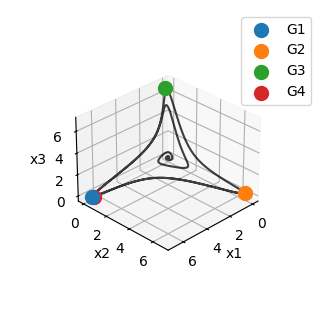

In [15]:
# set parameters
g_Farjami=1.49

# set time parameters
t_end = 550
dt = 0.1
timesteps = np.linspace(0,t_end,int(t_end/dt))

# simulate trajectory 
ICs = [0.05,0.05,0.07]
sol = solve_ivp(farjami_etal, (0, t_end), ICs,
                    t_eval=timesteps, args=(g_Farjami,),method='RK45',rtol=1e-6,atol=1e-6)

# run ghostID
Trj_farjami=sol.y.T
ghostSeq = gid.ghostID(farjami_etal,g_Farjami,dt,Trj_farjami,eigval_NN_sorting=True,epsilon_gid=0.15,delta_gid=1e-2,peak_kwargs={"distance":10,"prominence":4,"width":200})

# plot identified ghosts in 3D
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(projection='3d')
ax.plot(Trj_farjami[:,0],Trj_farjami[:,1],Trj_farjami[:,2],color='k',alpha=0.75)
for g in ghostSeq:
    ax.scatter(g["position"][0],g["position"][1],g["position"][2],s=100,marker="o",label=g["id"])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_box_aspect(None, zoom=0.65)
ax.view_init(elev=30, azim=45)
plt.legend()

As we can see, ghostID did not recognize the first ghost (G1) when the trajectory revisited it at a later stage and thus considered it to be different ghost,assigning a new identifier (G4) to it. Of, course choosing `delta_gid` too large will do the opposite and assign the same identifier to different ghosts:

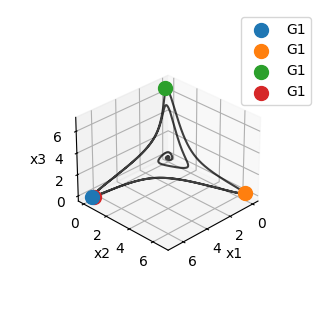

In [16]:
ghostSeq = gid.ghostID(farjami_etal,g_Farjami,dt,Trj_farjami,eigval_NN_sorting=True,epsilon_gid=0.15,delta_gid=10,peak_kwargs={"distance":10,"prominence":4,"width":200})

# plot identified ghosts in 3D
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(projection='3d')
ax.plot(Trj_farjami[:,0],Trj_farjami[:,1],Trj_farjami[:,2],color='k',alpha=0.75)
for g in ghostSeq:
    ax.scatter(g["position"][0],g["position"][1],g["position"][2],s=100,marker="o",label=g["id"])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_box_aspect(None, zoom=0.65)
ax.view_init(elev=30, azim=45)
plt.legend()

Choosing the right distance threshold is thus essential for identifying the correct number of ghosts and, as of now, requires the user's judgement.

The same issue can arise if we try to identify ghosts in a system using multiple trajectories. Suppose trajectory A first visits ghost x then ghost y, then ghostID assings identifiers G1 and G2 to x and y, respectively. Now suppose trajectory B only visits ghost y, then ghostID assigns identifier G1 to y. In such situations, PyGhostID'S `unify_IDs` can be used to unify identifiers across based on the same distance thresholding idea, i.e., using the analogous threshold `delta_unify`.

To illustrate this, we will use a simple model for cascading climate tipping points by [Wunderling et al](https://esd.copernicus.org/articles/12/601/2021/).

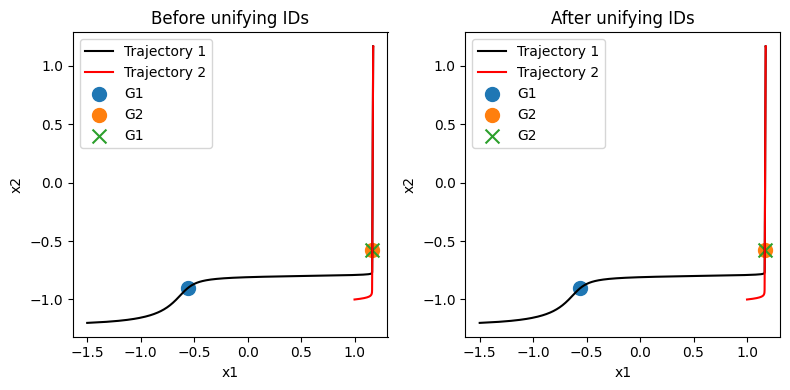

In [18]:
def wunderling_model(t, Z, para):
    Z = jnp.asarray(Z, dtype=jnp.float32)

    d,GMT,Tcrits,Taus,mat_inter=para

    intrinsic = -Z**3 + Z + np.sqrt(4/27)*GMT/Tcrits
    coupling = d/10* mat_inter @ (Z + 1) # Coupling effects: sum over j of C_ij * x_j

    # Total derivative
    dZdt = (intrinsic+coupling)/Taus

    return jnp.array(dZdt) 

# Set parameters and run test simulation
d = 0.15
GMT = 1.61
Tcrits = np.array([1.5,1.6]) 
Taus = np.array([100,1000])
interactions=np.array([[0,1],
                    [1,0]])

parameters_Wunderling = [d,GMT,Tcrits,Taus,interactions]

# simulate trajectory 
dt = 5
timesteps = np.linspace(0,1e5,int(1e5/dt))

sol1 = solve_ivp(wunderling_model, (0, 1e5), [-1.5,-1.2], t_eval=timesteps, args=(parameters_Wunderling,),method='RK45',rtol=1e-4,atol=1e-6)
sol2 = solve_ivp(wunderling_model, (0, 1e5), [1,-1], t_eval=timesteps, args=(parameters_Wunderling,),method='RK45',rtol=1e-4,atol=1e-6)

Trj1=sol1.y.T
ghostSeq1 = gid.ghostID(wunderling_model,parameters_Wunderling,dt,Trj1,0.03,peak_kwargs={"prominence":2,"width":20*dt}) #
Trj2=sol2.y.T
ghostSeq2 = gid.ghostID(wunderling_model,parameters_Wunderling,dt,Trj2,0.03,peak_kwargs={"prominence":2,"width":20*dt})

# plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Before unifying IDs")
plt.plot(sol1.y[0],sol1.y[1],'-k',label="Trajectory 1")
plt.plot(sol2.y[0],sol2.y[1],'-r',label="Trajectory 2")

for g in ghostSeq1:
    plt.scatter(g["position"][0],g["position"][1],s=100,marker="o",label=g["id"])
    
for g in ghostSeq2:
    plt.scatter(g["position"][0],g["position"][1],s=100,marker="x",label=g["id"])
plt.legend()
plt.xlabel("x1"); plt.ylabel("x2")


plt.subplot(1,2,2)
plt.title("After unifying IDs")
ghostSeq1_uni, ghostSeq2_uni = gid.unify_IDs([ghostSeq1,ghostSeq2],delta_unify=0.1)
plt.plot(sol1.y[0],sol1.y[1],'-k',label="Trajectory 1")
plt.plot(sol2.y[0],sol2.y[1],'-r',label="Trajectory 2")

for g in ghostSeq1_uni:
    plt.scatter(g["position"][0],g["position"][1],s=100,marker="o",label=g["id"])
    
for g in ghostSeq2_uni:
    plt.scatter(g["position"][0],g["position"][1],s=100,marker="x",label=g["id"])
plt.legend()
plt.xlabel("x1"); plt.ylabel("x2")
plt.tight_layout()

Like in the single-trajectory case you might have to tune `delta_unify`. Choosing an appropriate value of `delta_unify` becomes particularly important when using PyGhostID's `ghostID_phaseSpaceSample` function which samples many trajectories to identify ghosts and internally calls `unify_IDs`.

## Identifying the correct ghost-dimension and finding non-attracting ghosts



In higher dimensional systems with multiple elements close to saddle-node bifurcations the dimension identified by `ghostID` is often underestimated. This is because trajectories may not pass directly through the locally slowest point but only close by. As a consequence, the algorithm can miss one or more of the eigenvalues crossing from negative to positive.

Similarly, finding non-attracting ghosts is by their very nature difficult with a trajectory based algorithm. 

While we're thinking about a complementary mode to identify ghosts without trajectories, currently the only solution to both problems is to sample many trajectories with suitable initial conditions. To restrict the area from which to sample initial conditions, you can use PyGhostID's `qOnGrid` function to identify slow points in phase space and restrict your search to the neighborhood of these slow points.